### Basics to Start with

In [1]:
#list the words
text = ['All that we are is the result of what we have thought',
        'To be or not to be that is the question',
        'Be yourself everyone is already taken']
text

['All that we are is the result of what we have thought',
 'To be or not to be that is the question',
 'Be yourself everyone is already taken']

In [6]:
#seperate the words
import re
re.split(r'\s', text[0])
#text[0]

['All',
 'that',
 'we',
 'are',
 'is',
 'the',
 'result',
 'of',
 'what',
 'we',
 'have',
 'thought']

In [7]:
#recombine
' '.join(re.split(r'\s', text[0]))


'All that we are is the result of what we have thought'

In [8]:
# make lower case

allwords = re.split(r'\s',' '.join(text).lower())
allwords

['all',
 'that',
 'we',
 'are',
 'is',
 'the',
 'result',
 'of',
 'what',
 'we',
 'have',
 'thought',
 'to',
 'be',
 'or',
 'not',
 'to',
 'be',
 'that',
 'is',
 'the',
 'question',
 'be',
 'yourself',
 'everyone',
 'is',
 'already',
 'taken']

In [12]:
#create a vocabulary(lexicon)
#find the unique words

vocab = sorted( set( allwords))
print(len( allwords))
print(len( vocab))

28
20


In [49]:
# encoder
word2idx = {}
for i,word in enumerate(vocab):
  word2idx[word] = i

In [50]:
#decorder
idx2word = {}
for i,word in enumerate(vocab):
    idx2word[i]=word


In [23]:
# fake quotes
import numpy as np
randidx = np.random.randint(0, len(vocab),size = 10)

[idx2word[i] for i in randidx]
' '.join([idx2word[i] for i in randidx])

'question we thought that or result is already have taken'

In [25]:
# peak of tokenization
text_as_int = [word2idx[word] for word in allwords]
text_as_int

[0,
 13,
 17,
 2,
 6,
 14,
 11,
 8,
 18,
 17,
 5,
 15,
 16,
 3,
 9,
 7,
 16,
 3,
 13,
 6,
 14,
 10,
 3,
 19,
 4,
 6,
 1,
 12]

In [28]:
# numbers back into text
for tokeni in text_as_int:
  print(f'Token:{tokeni} : {idx2word[tokeni]}')

Token:0 : all
Token:13 : that
Token:17 : we
Token:2 : are
Token:6 : is
Token:14 : the
Token:11 : result
Token:8 : of
Token:18 : what
Token:17 : we
Token:5 : have
Token:15 : thought
Token:16 : to
Token:3 : be
Token:9 : or
Token:7 : not
Token:16 : to
Token:3 : be
Token:13 : that
Token:6 : is
Token:14 : the
Token:10 : question
Token:3 : be
Token:19 : yourself
Token:4 : everyone
Token:6 : is
Token:1 : already
Token:12 : taken


###Creating functions for Dictionary

In [56]:
def encoder(text):
    words = re.split(' ', text.lower())

    return [word2idx[w] for w in words]

In [58]:
#my_vocab = ['to', 'be']
encoder('to be')

[16, 3]

In [59]:
def decoder(indices):
    return [idx2word[i] for i in indices]


In [61]:

decoder([16,3])

['to', 'be']

In [62]:
decoder(encoder('to be'))

['to', 'be']

###Visualize Tokenized integers

In [63]:
import matplotlib.pyplot as plt
%matplotlib inline


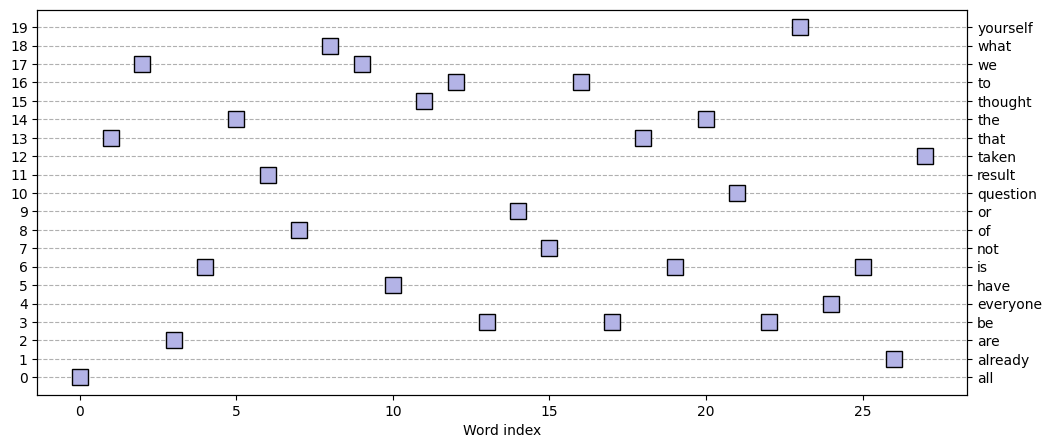

In [65]:
alltext = ' '.join(text)
tokens = encoder(alltext)
#vocab = sorted(set(allwords))

# create a figure
_, ax = plt.subplots(1, figsize=(12, 5))

# plot the tokens
ax.plot(tokens, 'ks', markersize=12, markerfacecolor=[.7, .7, .9])
ax.set(xlabel='Word index', yticks=range(len(vocab)))
ax.grid(linestyle='--', axis='y')

# invisible axis for right-hand-side labels
ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(vocab)), yticklabels=vocab)

plt.show()


### Explore context surroundinf target tokens

In [74]:
targetWord = 'to'
targetIdx = word2idx[targetWord]

# find indices
targetLocs = np.where(np.array(allwords) == targetWord)[0]
print(f"'{targetWord}' appears at indices {targetLocs}\n\n")

# print context
for t in targetLocs:
    print(tokens[t-1:t+2])
    print(' '.join(allwords[t-1:t+2]), '\n')


'to' appears at indices [12 16]


[15, 16, 3]
thought to be 

[7, 16, 3]
not to be 

